In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update('jax_default_device', 'cpu')
jax.config.update('jax_default_matmul_precision', 'highest')

In [2]:
import jax.numpy as jnp
import jax.random as jr
import jax.tree_util as jtu
import equinox as eqx
import matplotlib.pyplot as plt
import seaborn as sns

from functools import partial
from jax import vmap
from scipy.linalg import orthogonal_procrustes

from sppcax.distributions import MultivariateNormalInverseGamma as MVNIG

from sppcax.models import BayesianFactorAnalysis as BFA
from sppcax.models.dynamic_factor_analysis import (
    ParamsLGSSM, ParamsLGSSMInitial, ParamsLGSSMDynamics,
    ParamsLGSSMEmissions,
)
from sppcax.inference.utils import ParamsLGSSMVB

# Testing PX-VBEM for Bayesian Factor Analysis

This notebook tests the **Parameter-Expanded VBEM (PX-VBEM)** algorithm
applied to Bayesian Factor Analysis (static DFA with $\mathbf{F}=0$, $\mathbf{Q}=\mathbf{I}$).

The PX-VB rotation matrix $\mathbf{R}$ is found by numerically minimizing
the objective $\mathbb{E}_q[-\ln p(\tilde{\mathbf{H}}, \tilde{\mathbf{x}} \mid \mathbf{R})]$
using gradient descent with Anderson acceleration (m=1).

In the static case only two loss terms contribute:
- $\mathcal{L}_\text{init}$: initial state prior
- $\mathcal{L}_\text{em}$: emission prior

The converged $\mathbf{R}$ transforms the emission posterior as:
$\tilde{\mathbf{H}} = \mathbf{H} \mathbf{R}_\text{block}$ where $\mathbf{R}_\text{block} = \text{blkdiag}(\mathbf{R}, \mathbf{I})$.

If the optimization does not reduce the loss, $\mathbf{R}$ falls back to identity.

## 1. Generate Synthetic FA Data

Y shape: (200, 20), H_true shape: (20, 5)
H_true sparsity: 76.0% zeros


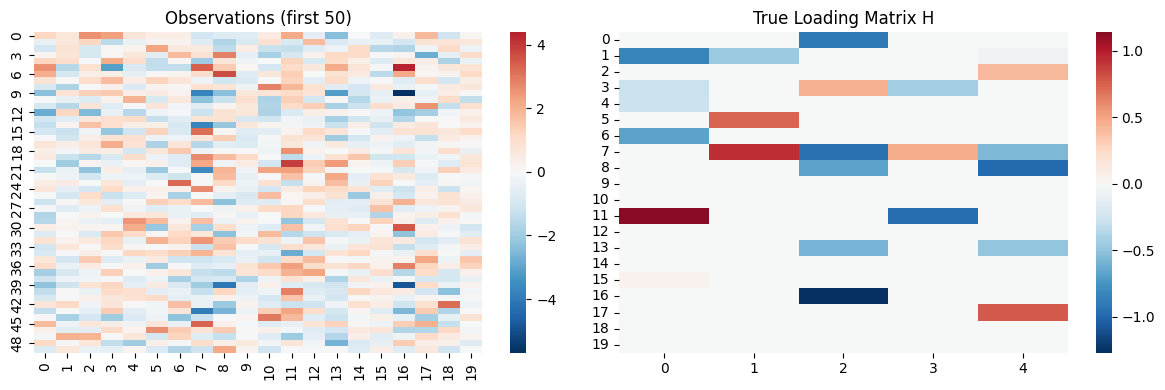

In [3]:
# Data dimensions
N = 200   # observations
D = 20    # features
K = 5     # latent components

key = jr.PRNGKey(42)

# True sparse loading matrix
key, k1, k2 = jr.split(key, 3)
H_true = jr.normal(k1, (D, K)) * jr.bernoulli(k2, p=0.3, shape=(D, K))

# True diagonal noise covariance
key, k1 = jr.split(key)
R_true_diag = jr.uniform(k1, (D,), minval=0.3, maxval=1.0)

# Generate data: z ~ N(0, I), x = H z + noise
key, k1, k2 = jr.split(key, 3)
Z_true = jr.normal(k1, (N, K))
noise = jr.normal(k2, (N, D)) * jnp.sqrt(R_true_diag)
Y = Z_true @ H_true.T + noise

print(f"Y shape: {Y.shape}, H_true shape: {H_true.shape}")
print(f"H_true sparsity: {jnp.isclose(H_true, 0.).mean():.1%} zeros")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(Y[:50], ax=axes[0], cmap='RdBu_r', center=0)
axes[0].set_title('Observations (first 50)')
sns.heatmap(H_true, ax=axes[1], cmap='RdBu_r', center=0, annot=False)
axes[1].set_title('True Loading Matrix H')
plt.tight_layout()

## 2. Experiments Without BMR

In [4]:
NUM_ITERS = 20
use_ard = True

# --- Standard EM ---
model1 = BFA(2 * K, D, has_ard=use_ard, use_px=False)
key, k1, k2 = jr.split(key, 3)
params_init, props = model1.initialize(k1)
params_em, elbos_em = model1.fit_em(params_init, props, Y, k2, num_iters=NUM_ITERS)
print(f"EM final ELBO: {elbos_em[-1]:.1f}")

# --- PX-EM ---
model2 = BFA(2 * K, D, use_px=True, has_ard=use_ard)
key, k1, k2 = jr.split(key, 3)
params_pxl, elbos_pxl = model2.fit_em(params_init, props, Y, k2, num_iters=NUM_ITERS)
print(f"PX-EM final ELBO: {elbos_pxl[-1]:.1f}")

# --- Standard VBEM ---
model1 = BFA(2 * K, D, has_ard=use_ard, use_px=False)
key, k1, k2 = jr.split(key, 3)
params_vbem_init, props_vbem = model1.initialize(k1, variational_bayes=True)
params_vbem, elbos_vbem = model1.fit_vbem(params_vbem_init, props_vbem, Y, k2, num_iters=NUM_ITERS)
print(f"VBEM final ELBO: {elbos_vbem[-1]:.1f}")

# --- PX-VBEM ---
model2 = BFA(2 * K, D, use_px=True, has_ard=use_ard)
key, k1, k2 = jr.split(key, 3)
params_pxl_vb, elbos_pxl_vb = model2.fit_vbem(params_vbem_init, props_vbem, Y, k2, num_iters=NUM_ITERS)
print(f"PX-VBEM final ELBO: {elbos_pxl_vb[-1]:.1f}")

EM final ELBO: -5831.9
PX-EM final ELBO: -5815.8
VBEM final ELBO: -6403.4
PX-VBEM final ELBO: -6388.7


### Convergence Comparison (No BMR)

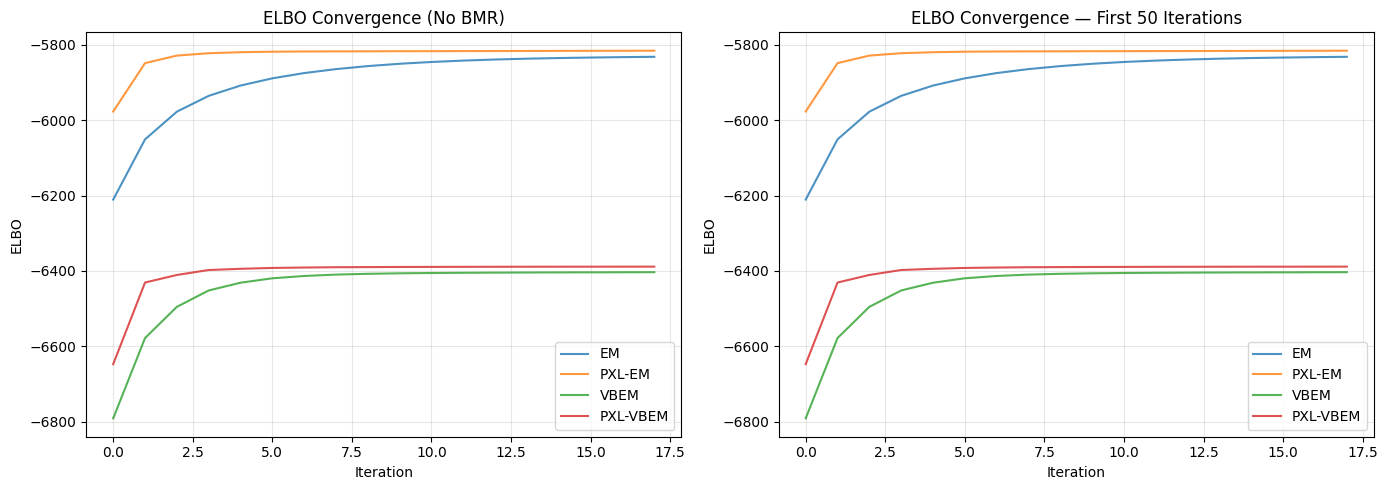

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ELBO convergence
ax = axes[0]
ax.plot(elbos_em[1:], label='EM', alpha=0.8)
ax.plot(elbos_pxl[1:], label='PXL-EM', alpha=0.8)
ax.plot(elbos_vbem[1:], label='VBEM', alpha=0.8)
ax.plot(elbos_pxl_vb[1:], label='PXL-VBEM', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (No BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

# Zoomed view of first 50 iterations
ax = axes[1]
ax.plot(elbos_em[1:50], label='EM', alpha=0.8)
ax.plot(elbos_pxl[1:50], label='PXL-EM', alpha=0.8)
ax.plot(elbos_vbem[1:50], label='VBEM', alpha=0.8)
ax.plot(elbos_pxl_vb[1:50], label='PXL-VBEM', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence — First 50 Iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

### Loading Matrix Recovery (No BMR)

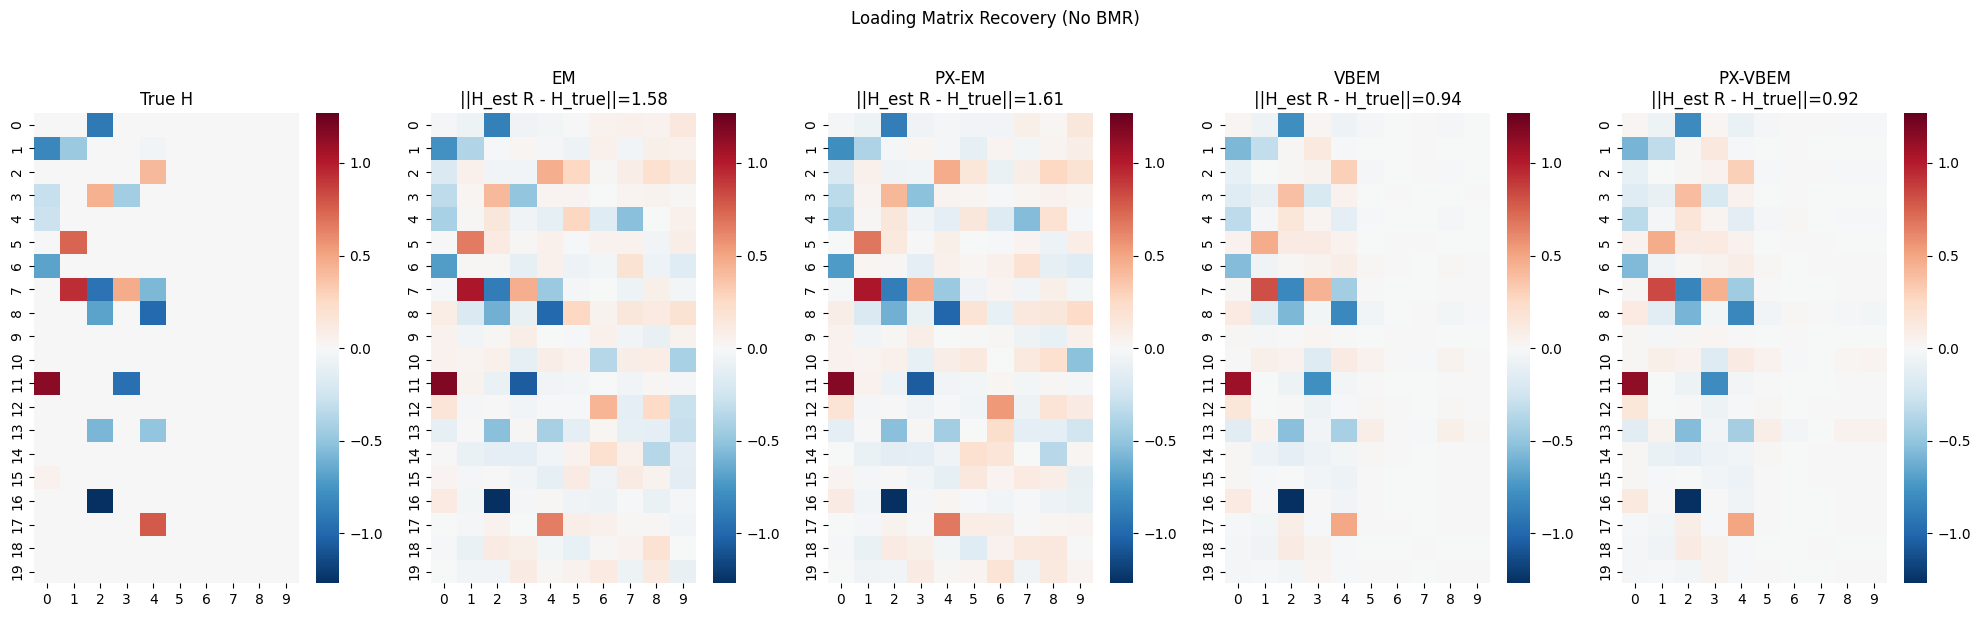

In [6]:
def procrustes_similarity(H_est, H_true):
    """Align H_est to H_true via orthogonal Procrustes.
    
    Handles different number of columns by zero-padding the smaller matrix.
    Returns aligned H_est and Frobenius disparity.
    """
    D, K_est = H_est.shape
    K_true = H_true.shape[1]
    K_max = max(K_est, K_true)
    
    # Pad to equal column count
    A = jnp.pad(H_est, [(0, 0), (0, K_max - K_est)]) if K_est < K_max else H_est
    B = jnp.pad(H_true, [(0, 0), (0, K_max - K_true)]) if K_true < K_max else H_true
    
    R, _ = orthogonal_procrustes(A, B)
    H_aligned = A @ R
    disparity = jnp.linalg.norm(H_aligned - B, 'fro')
    return H_aligned, float(disparity)


results_no_bmr = {
    'EM': params_em.emissions.weights,
    'PX-EM': params_pxl.emissions.weights,
    'VBEM': params_vbem.emissions.weights,
    'PX-VBEM': params_pxl_vb.emissions.weights,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(jnp.pad(H_true, [(0, 0), (0, K)]), ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

for idx, (name, H_est) in enumerate(results_no_bmr.items()):
    H_aligned, disparity = procrustes_similarity(H_est, H_true)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||H_est R - H_true||={disparity:.2f}')

plt.suptitle('Loading Matrix Recovery (No BMR)', y=1.02)
plt.tight_layout()

## 3. Experiments With BMR

In [7]:
NUM_ITERS_BMR = 20

# --- Standard EM + BMR ---
model_bmr = BFA(2 * K, D, has_ard=use_ard, use_bmr=True, use_px=False)
key, k1, k2 = jr.split(key, 3)
params_init_bmr, props_bmr = model_bmr.initialize(k1)
params_em_bmr, elbos_em_bmr = model_bmr.fit_em(
    params_init_bmr, props_bmr,
    Y, k2, num_iters=NUM_ITERS_BMR,
    bmr_start_iter=8)
print(f"EM+BMR final ELBO: {elbos_em_bmr[-1]:.1f}")

# --- PXL-EM + BMR ---
model_bmr = BFA(2 * K, D, has_ard=use_ard, use_bmr=True, use_px=True)
params_pxl_bmr, elbos_pxl_bmr = model_bmr.fit_em(
    params_init_bmr, props_bmr,
    Y, k2,
    num_iters=NUM_ITERS_BMR,
    bmr_start_iter=8)
print(f"PXL-EM+BMR final ELBO: {elbos_pxl_bmr[-1]:.1f}")

EM+BMR final ELBO: -5567.3
PXL-EM+BMR final ELBO: -5491.3


In [8]:
# --- Standard VBEM + BMR ---
key, k1, k2 = jr.split(key, 3)
model_bmr = BFA(2 * K, D, has_ard=use_ard, use_bmr=True, use_px=False)
params_vbem_bmr_init, props_vbem_bmr = model_bmr.initialize(k1, variational_bayes=True)
params_vbem_bmr, elbos_vbem_bmr = model_bmr.fit_vbem(
    params_vbem_bmr_init, props_vbem_bmr,
    Y, k2,
    num_iters=NUM_ITERS_BMR,
    bmr_start_iter=8)
print(f"VBEM+BMR final ELBO: {elbos_vbem_bmr[-1]:.1f}")

# --- PXL-VBEM + BMR ---
model_bmr = BFA(2 * K, D, has_ard=use_ard, use_bmr=True, use_px=True)
params_pxl_vb_bmr, elbos_pxl_vb_bmr = model_bmr.fit_vbem(
    params_vbem_bmr_init, props_vbem_bmr,
    Y, k2,
    num_iters=NUM_ITERS_BMR,
    bmr_start_iter=8)
print(f"PXL-VBEM+BMR final ELBO: {elbos_pxl_vb_bmr[-1]:.1f}")

VBEM+BMR final ELBO: -5979.3
PXL-VBEM+BMR final ELBO: -5943.8


### Convergence Comparison (With BMR)

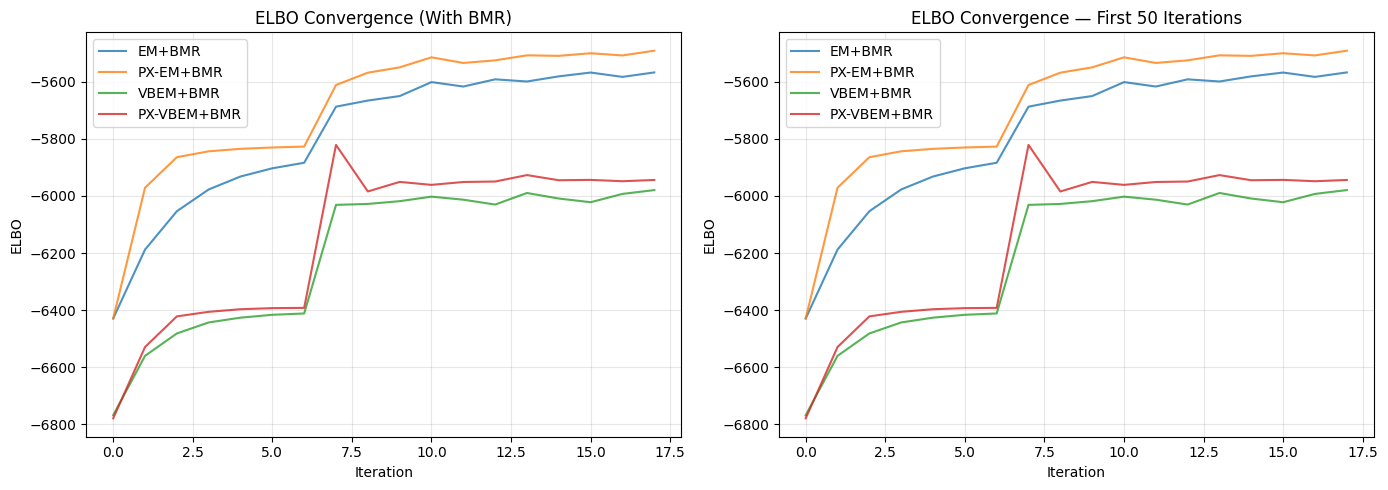

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_em_bmr[1:], label='EM+BMR', alpha=0.8)
ax.plot(elbos_pxl_bmr[1:], label='PX-EM+BMR', alpha=0.8)
ax.plot(elbos_vbem_bmr[1:], label='VBEM+BMR', alpha=0.8)
ax.plot(elbos_pxl_vb_bmr[1:], label='PX-VBEM+BMR', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (With BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_em_bmr[1:50], label='EM+BMR', alpha=0.8)
ax.plot(elbos_pxl_bmr[1:50], label='PX-EM+BMR', alpha=0.8)
ax.plot(elbos_vbem_bmr[1:50], label='VBEM+BMR', alpha=0.8)
ax.plot(elbos_pxl_vb_bmr[1:50], label='PX-VBEM+BMR', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence — First 50 Iterations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

### Loading Matrix Recovery (With BMR)

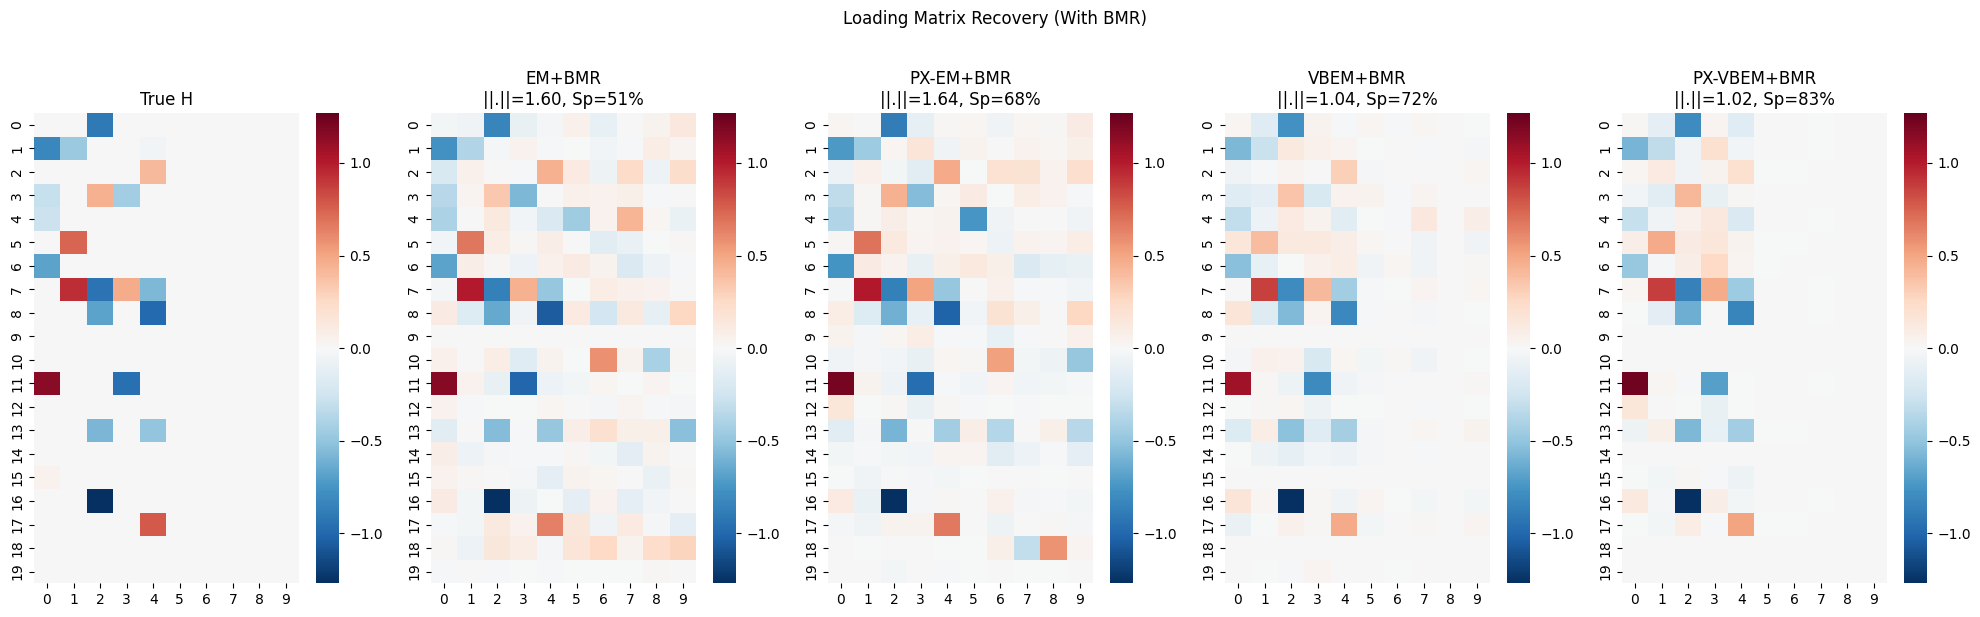

In [10]:
results_bmr = {
    'EM+BMR': params_em_bmr.emissions.weights,
    'PX-EM+BMR': params_pxl_bmr.emissions.weights,
    'VBEM+BMR': params_vbem_bmr.emissions.weights,
    'PX-VBEM+BMR': params_pxl_vb_bmr.emissions.weights,
}

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(jnp.pad(H_true, [(0, 0), (0, K)]), ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H')

for idx, (name, H_est) in enumerate(results_bmr.items()):
    H_aligned, disparity = procrustes_similarity(H_est, H_true)
    sparsity = jnp.mean(jnp.abs(H_est) < 0.05)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}, Sp={sparsity:.0%}')

plt.suptitle('Loading Matrix Recovery (With BMR)', y=1.02)
plt.tight_layout()

## 7. Summary

**PX-VB rotation (static FA):**
The rotation $\mathbf{R}$ is found by numerically minimizing
$\mathcal{L}(\mathbf{R}) = \mathbb{E}_q[-\ln p(\tilde{\mathbf{H}}, \tilde{\mathbf{x}} \mid \mathbf{R})]$
via gradient descent with Anderson acceleration (m=1). For static FA only the
initial and emission terms contribute. The converged $\mathbf{R}$ transforms:
- $\tilde{\mathbf{H}} = \mathbf{H} \mathbf{R}_\text{block}$, $\mathbf{R}_\text{block} = \text{blkdiag}(\mathbf{R}, \mathbf{I})$

If the optimization does not reduce the loss, $\mathbf{R}$ falls back to identity.

**Expected findings:**
- PX-EM should converge faster than standard EM (fewer iterations to reach same ELBO)
- PX-EM may find sparser solutions when combined with BMR
- The VB variants (VBEM, PX-VBEM) provide uncertainty quantification through the correction terms